In [1]:
import pandas as pd
import numpy as np
import requests, re
from typing import List, Literal
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm
from mpl_toolkits.basemap import Basemap


In [2]:
# Step 1: Define API

# API Fetch
def fetch_mhw_data(lon0, lat0, lon1, lat1, start, end):
    url = f"https://eco.odb.ntu.edu.tw/api/mhw"
    params = {
        "lon0": lon0,
        "lat0": lat0,
        "lon1": lon1,
        "lat1": lat1,
        "start": start,
        "end": end,
        "append": "sst,sst_anomaly,level",
    }
    response = requests.get(url, params=params)
    if response.status_code == 200:
        return pd.DataFrame(response.json())
    else:
        print("Failed to fetch data:", response.text)
        return None


In [65]:
# region for Niño 3.4 (5°N–5°S, 170°W–120°W)
# Convert 170°W to 190°E for consistency
lon0, lon1 = -170, -120  # 190°E to 240°E
lat0, lat1 = -5, 5
start, end = "2025-05-01", "2025-05-30"
data = fetch_mhw_data(lon0, lat0, lon1, lat1, start, end)
print(data.head())

       lon    lat        date  level        sst  sst_anomaly
0 -169.875 -4.875  2025-05-01      1  29.800001       0.6174
1 -169.625 -4.875  2025-05-01      1  29.786451       0.6125
2 -169.375 -4.875  2025-05-01      1  29.752903       0.5893
3 -169.125 -4.875  2025-05-01      1  29.705482       0.5486
4 -168.875 -4.875  2025-05-01      0  29.651613       0.4963


In [66]:
# Test a stronger La Niña event
# Plot a wider region, but it across 180°E antimeridian, so we need to split the data fetching 
start, end = "2007-11-01", "2007-11-30"
lat0, lat1 = -25, 25
lon0, lon1 = 135, -60  # 180°E to 300°E

In [67]:
# def get_combined_ssta_data():
d1 = fetch_mhw_data(-179.999, lat0, lon1, lat1, start, end)
d2 = fetch_mhw_data(lon0, lat0, 179.999, lat1, start, end)
# return 
data = pd.concat([d1, d2], ignore_index=True)
print(data.head())

       lon     lat        date  level        sst  sst_anomaly
0 -179.875 -24.875  2007-11-01      0  23.651667       0.5933
1 -179.625 -24.875  2007-11-01      0  23.596001       0.5407
2 -179.375 -24.875  2007-11-01      0  23.575001       0.5301
3 -179.125 -24.875  2007-11-01      0  23.608667       0.5765
4 -178.875 -24.875  2007-11-01      0  23.667332       0.6417


In [68]:
data["date"] = pd.to_datetime(data["date"])
data['lon_360'] = data['lon'].apply(lambda x: x + 360 if x < 0 else x)

In [69]:
# Reshape to grid
def reshape_to_grid_fixed(data, column, date, lon_col='lon'):
    data_filtered = data[data["date"] == date]
    all_lats = np.sort(data["lat"].unique())
    all_lons = np.sort(data[lon_col].unique())
    grid = pd.DataFrame(index=all_lats, columns=all_lons)
    for _, row in data_filtered.iterrows():
        grid.at[row["lat"], row[lon_col]] = row[column]
    return grid.astype(float)

In [71]:
grid = reshape_to_grid_fixed(data, 'sst_anomaly', start, lon_col='lon_360')
print(grid.tail())

        135.125  135.375  135.625  135.875  136.125  136.375  136.625  \
23.875   0.7820   0.8548   0.8995   0.9592   1.0286   1.0941   1.1825   
24.125   0.8148   0.8717   0.9040   0.9651   1.0330   1.1054   1.1971   
24.375   0.8020   0.8367   0.8468   0.8719   0.9233   0.9737   1.0419   
24.625   0.7676   0.7680   0.7481   0.7460   0.7640   0.7744   0.7981   
24.875   0.7474   0.7137   0.6517   0.6297   0.6153   0.5912   0.5564   

        136.875  137.125  137.375  ...  297.625  297.875  298.125  298.375  \
23.875   1.2118   1.1701   1.1434  ...   0.1966   0.2782   0.4109   0.5619   
24.125   1.2249   1.2097   1.2199  ...   0.3225   0.4241   0.5498   0.6710   
24.375   1.0858   1.1122   1.1703  ...   0.4916   0.5580   0.6499   0.7133   
24.625   0.8295   0.8734   0.9494  ...   0.6624   0.7110   0.7322   0.7262   
24.875   0.5423   0.5559   0.6182  ...   0.8066   0.8107   0.7813   0.7158   

        298.625  298.875  299.125  299.375  299.625  299.875  
23.875   0.6930   0.7605   0.

In [73]:
def draw_nino_regions(m):
    """畫出 Niño 區域在 basemap 上"""
    boxes = {
        'Niño 1+2': (270, 280, -10, 0),    # 90W~80W
        'Niño 3':   (210, 270, -5, 5),     # 150W~90W
        'Niño 4':   (160, 210, -5, 5),     # 160E~150W
        'Niño 3.4': (190, 240, -5, 5),     # 170W~120W
    }
    colors = {
        'Niño 1+2': 'deepskyblue',
        'Niño 3':   'darkorange',
        'Niño 4':   'limegreen',
        'Niño 3.4': 'crimson',
    }
    linestyles = {
        'Niño 1+2': 'dashed',
        'Niño 3':   'dashed',
        'Niño 4':   'dashed',
        'Niño 3.4': 'dashdot',
    }

    for name, (lon_min, lon_max, lat_min, lat_max) in boxes.items():
        x = [lon_min, lon_max, lon_max, lon_min, lon_min]
        y = [lat_min, lat_min, lat_max, lat_max, lat_min]
        m.plot(x, y, latlon=True, linestyle=linestyles[name],
               linewidth=1.5, label=name, color=colors[name])
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=4, fontsize='small')


In [74]:
def plot_ssta_grid(grid, date, lon0, lon1, lat0, lat1):
    plt.figure(figsize=(12, 5))
    fig, ax = plt.subplots(figsize=(12, 4))
    m = Basemap(projection="cyl", llcrnrlon=lon0, urcrnrlon=lon1,
                llcrnrlat=lat0, urcrnrlat=lat1, resolution="l", ax=ax)
    m.drawcoastlines()
    m.drawparallels(np.arange(lat0, lat1+1, 5), labels=[1,0,0,0])
    m.drawmeridians(np.arange(lon0, lon1+1, 10), labels=[0,0,0,1])
    m.drawmapboundary(fill_color='white')

    # 經緯度格點
    lon2d, lat2d = np.meshgrid(grid.columns.astype(float), grid.index.astype(float))

    # 繪製底圖
    cs = m.contourf(lon2d, lat2d, grid.values.astype(float), cmap=cm.RdYlBu_r,
                    levels=np.linspace(-3, 3, 21), extend='both', latlon=True)
    
    # Add rectangle for Niño 3.4 region (5°N–5°S, 170°W–120°W)
    # nino_lon0, nino_lon1 = -170 % 360, -120 % 360
    # nino_lat0, nino_lat1 = -5, 5
    # m.plot([nino_lon0, nino_lon1, nino_lon1, nino_lon0, nino_lon0],
    #        [nino_lat0, nino_lat0, nino_lat1, nino_lat1, nino_lat0],
    #        color="magenta", linewidth=2, linestyle="--")
    draw_nino_boxes(m)

    cbar = plt.colorbar(cs, orientation="vertical", shrink=0.8, pad=0.02)
    cbar.set_label("SST Anomaly (°C)")
    plt.title(f"SST Anomalies in Central Pacific (Nino3.4) - {date.strftime('%b %Y')}")
    plt.tight_layout()
    plt.show()


<Figure size 1200x500 with 0 Axes>

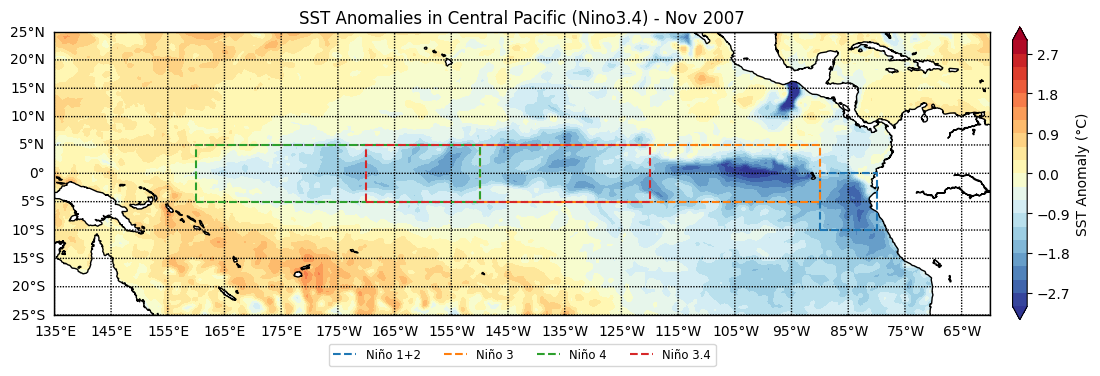

In [75]:
plot_ssta_grid(grid, pd.to_datetime(start), lon0, lon1+360, lat0, lat1)

In [9]:
def get_soi_data(start=2010, end=2025):
    """
    Download standardized monthly SOI index from NOAA.
    start and end can be:
      - 4-digit year (e.g., 2010)
      - or 6-digit year+month (e.g., 201003 for March 2010)
    """
    def to_timestamp(val, default_month):
        """Convert 4- or 6-digit year/month to pd.Timestamp"""
        val = int(val)
        if val < 10000:
            return pd.Timestamp(year=val, month=default_month, day=15)
        else:
            return pd.Timestamp(year=val // 100, month=val % 100, day=15)

    # Normalize start and end to Timestamps
    start_ts = to_timestamp(start, default_month=1)
    end_ts   = to_timestamp(end,   default_month=12)

    try:
        url = "https://www.cpc.ncep.noaa.gov/data/indices/soi"
        response = requests.get(url, timeout=30)
        lines = response.text.strip().split('\n')

        # === Step 1: Locate standardized SOI section
        for i, line in enumerate(lines):
            if "STANDARDIZED" in line:
                start_idx = i + 2
                break
        else:
            raise ValueError("Standardized SOI section not found")

        # === Step 2: Parse monthly data
        data = []
        for line in lines[start_idx:]:
            line = re.sub(r'(?<=[0-9])-(?=[0-9])', ' -', line)
            parts = line.split()
            if not parts or not parts[0].isdigit():
                continue
            year = int(parts[0])
            if len(parts) < 13:
                continue
            for m in range(1, 13):
                try:
                    val = float(parts[m])
                    if val == -999.9:
                        continue
                    date = pd.Timestamp(year, m, 15)
                    if start_ts <= date <= end_ts:
                        data.append({"date": date, "SOI": val})
                except ValueError:
                    continue

        return pd.DataFrame(data).set_index("date")

    except Exception as e:
        print("Using synthetic SOI due to error:", e)
        dates = pd.date_range(start_ts, end_ts, freq="MS")
        t = np.arange(len(dates))
        soi = 2 * np.sin(2*np.pi*t/24) + np.random.normal(0, 0.5, len(dates))
        return pd.DataFrame({'SOI': soi}, index=dates)


In [10]:
soi = get_soi_data(1950,2025)
# print(soi)

<Axes: xlabel='date'>

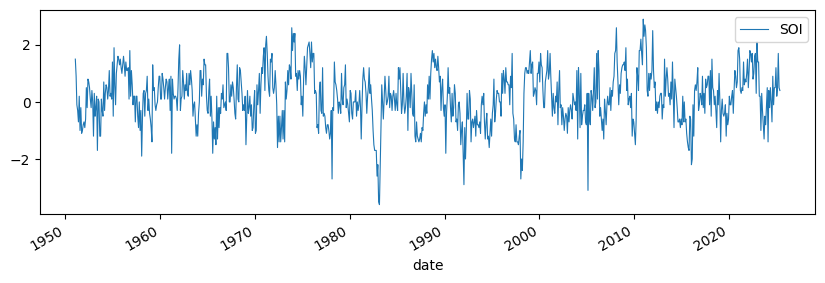

In [5]:
fig,ax = plt.subplots(figsize=(10,3))
soi.plot(ax=ax, lw=.8)


In [ ]:
def plot_eemd_decomposition_series(series: pd.Series, label="SOI", max_imfs=None):
    from PyEMD import EEMD
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import numpy as np

    # Interpolate any gaps
    series = series.interpolate("time").dropna()
    x = series.values
    t = np.arange(len(x))

    eemd = EEMD(trials=100, noise_width=0.2)
    eemd.eemd(x, t)
    IMFs, residual = eemd.get_imfs_and_residue()

    n_imfs = IMFs.shape[0] if max_imfs is None else min(IMFs.shape[0], max_imfs)
    fig, axes = plt.subplots(n_imfs + 1, 1, figsize=(12, 2.2*(n_imfs+1)), sharex=True)

    for i in range(n_imfs):
        axes[i].plot(series.index, IMFs[i], label=f"IMF {i+1}")
        axes[i].legend(loc="upper right")
        axes[i].grid(alpha=0.3)

    axes[-1].plot(series.index, residual, 'k', label="Residual (trend)")
    axes[-1].legend(loc="upper right")
    axes[-1].grid(alpha=0.3)

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    fig.suptitle(f"EEMD decomposition of {label} series", fontsize=14)
    fig.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

    return series, IMFs, residual


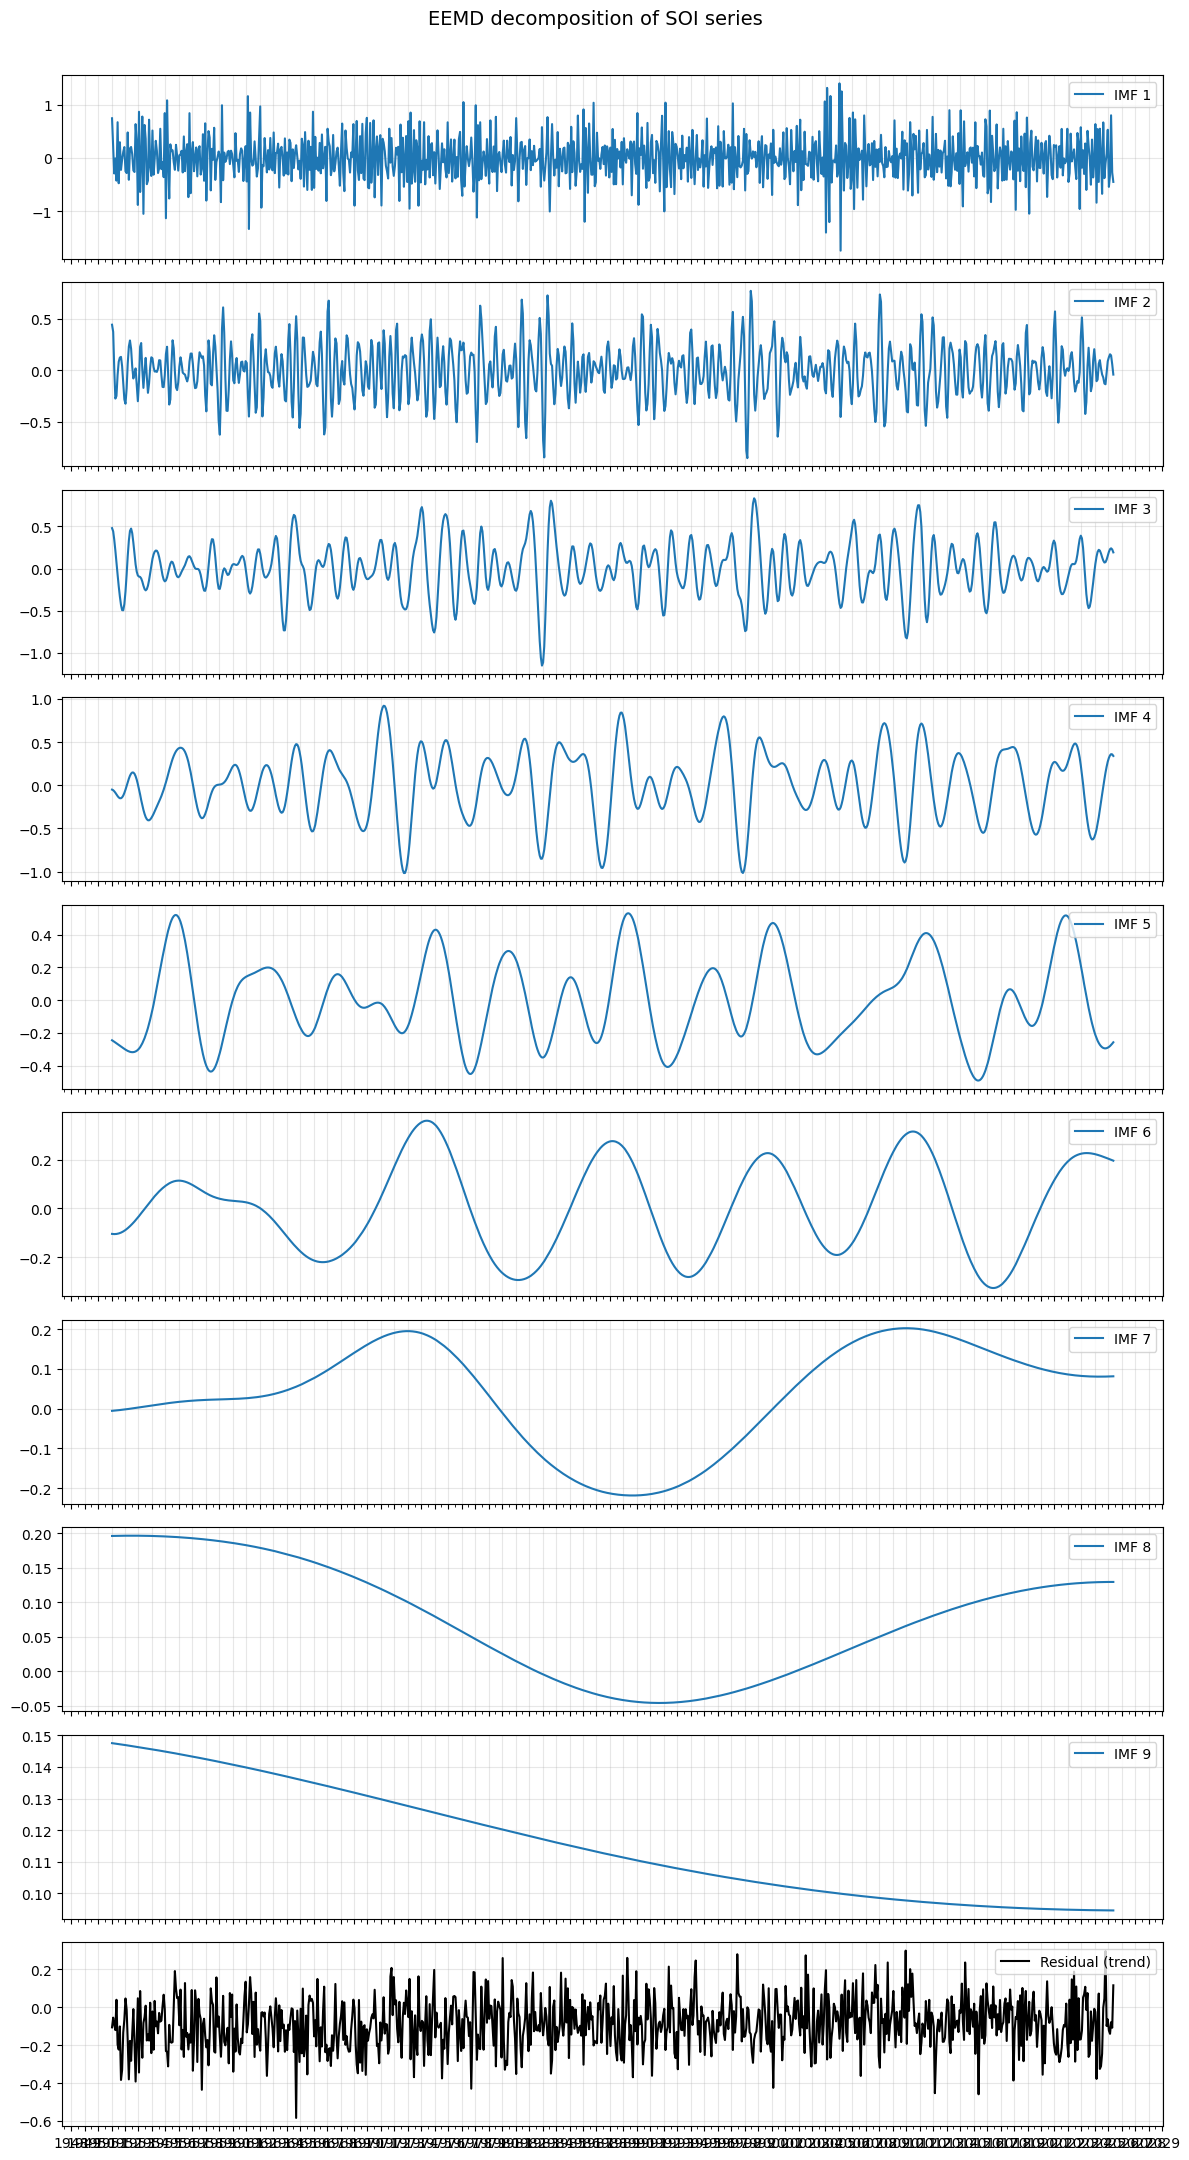

In [51]:
soi_series, IMF_soi, resid_soi = plot_eemd_decomposition_series(soi['SOI'], label="SOI")

In [57]:
def imf_fft_peak_periods(IMFs: np.ndarray,
                         dt: float = 1.0,
                         units: Literal["days", "months"] = "days") -> pd.DataFrame:
    """
    Compute dominant periods of IMFs using FFT.

    Args:
        IMFs: array of shape (n_imfs, n_samples)
        dt: sampling interval (1.0 = daily, 1/30 = monthly if unit is 'days')
        units: 'days' or 'months' — determines output unit

    Returns:
        DataFrame with:
            - IMF: 1-based index
            - peak_freq: cycles per unit (e.g., per day or month)
            - peak_period: inverse of peak frequency, in chosen unit
    """
    import numpy as np
    import pandas as pd

    n_imfs, N = IMFs.shape
    freqs = np.fft.rfftfreq(N, d=dt)
    result = []

    for i, imf in enumerate(IMFs, start=1):
        P = np.abs(np.fft.rfft(imf))**2
        idx = np.argmax(P[1:]) + 1  # skip DC
        f = freqs[idx]
        period = 1/f if f > 0 else np.inf
        result.append({
            "IMF": i,
            "peak_freq": f,
            f"peak_period_{units}": period
        })

    return pd.DataFrame(result)


In [58]:
fft_stats = imf_fft_peak_periods(IMF_soi, dt=1.0, units="months")
print(fft_stats)

   IMF  peak_freq  peak_period_months
0    1   0.404255            2.473684
1    2   0.111982            8.930000
2    3   0.054871           18.224490
3    4   0.022396           44.650000
4    5   0.007839          127.571429
5    6   0.006719          148.833333
6    7   0.002240          446.500000
7    8   0.001120          893.000000
8    9   0.001120          893.000000


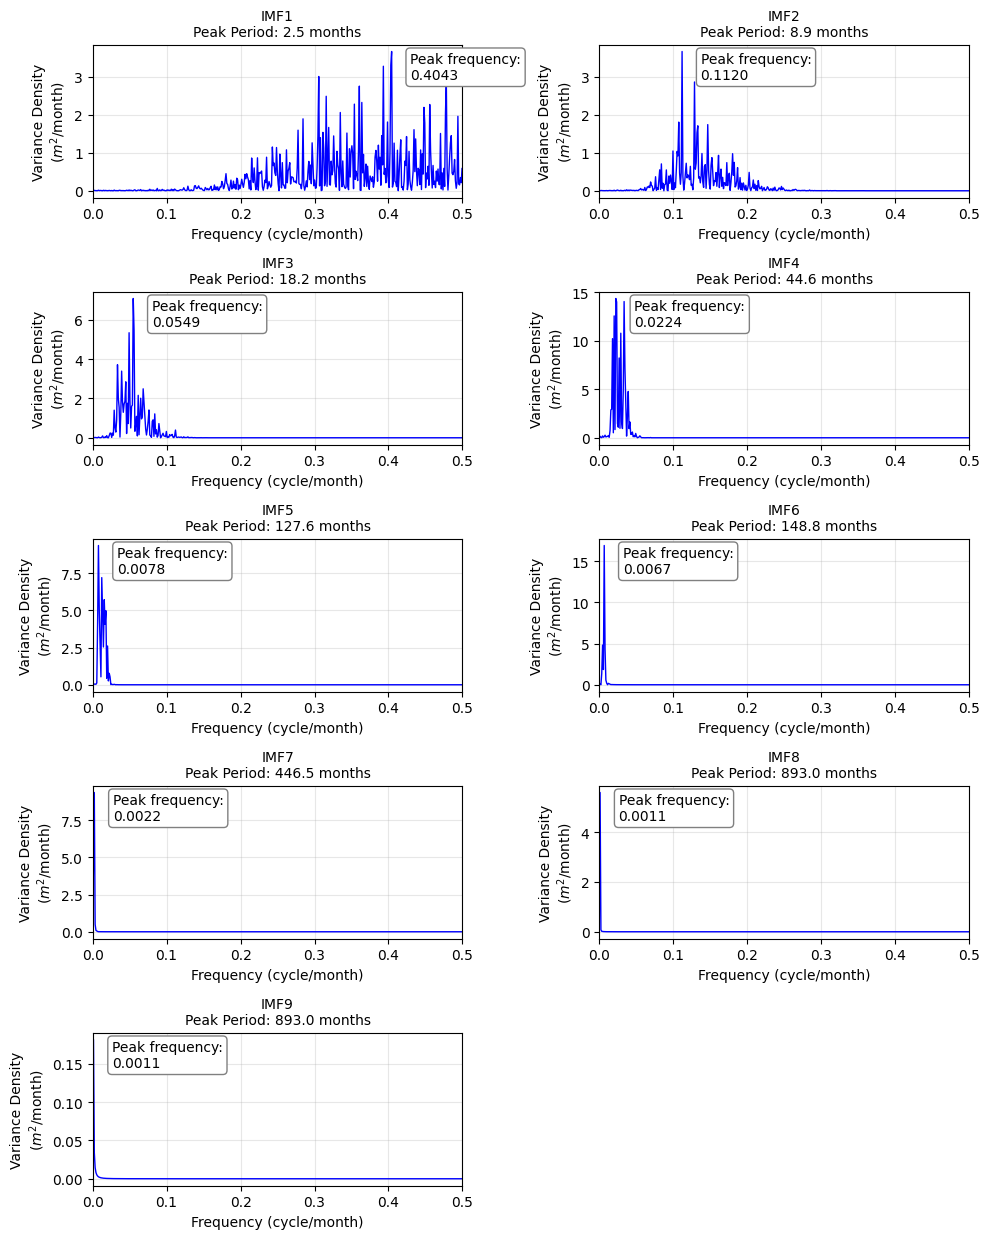

In [61]:
from scipy.signal import periodogram

# Simulated IMF data (for demo, replace with your real IMF matrix)
# np.random.seed(0)
# t = np.arange(0, 3650)  # 10 years of daily data
# IMFs = [np.sin(2 * np.pi * t / p) + 0.1 * np.random.randn(len(t)) for p in [90, 120, 180, 240, 365, 512, 730, 1000]]

# Plot IMF FFTs
n = len(IMF_soi)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 2.5 * nrows))
axes = axes.ravel()

for i, imf in enumerate(IMF_soi):
    f, Pxx = periodogram(imf, fs=1.0)  # fs=1 sample/day
    freq_monthly = f * 1  # cycles/month
    ax = axes[i]
    ax.plot(freq_monthly, Pxx, color='blue', lw=1)
    ax.set_xlim(0, 0.5)
    ax.set_xlabel("Frequency (cycle/month)")
    ax.set_ylabel("Variance Density\n($m^2$/month)")

    # Estimate peak period
    peak_idx = np.argmax(Pxx[1:]) + 1  # skip DC
    peak_freq = freq_monthly[peak_idx]
    peak_period = 1 / peak_freq if peak_freq > 0 else np.nan

    if peak_freq > 0 and peak_freq < 0.5:
        ax.text(peak_freq + 0.025, Pxx.max()*0.8,  # x and y placement
                f"Peak frequency:\n{peak_freq:.4f}",
                fontsize=10, bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'),
                transform=ax.transData)
    ax.set_title(f"IMF{i+1}\nPeak Period: {peak_period:.1f} months", fontsize=10)
    ax.grid(True, alpha=0.3)

for i in range(len(IMF_soi), len(axes)):
    axes[i].axis("off")

plt.tight_layout()

In [3]:
# 2. Function to get Niño 3.4 SST anomalies from PSL data
def get_nino34_anomalies(start="1950", end="2025"):
    url = "https://psl.noaa.gov/data/timeseries/month/data/nino34.long.anom.data"
    response = requests.get(url, timeout=30)
    lines = response.text.strip().split('\n')[1:]  # skip header

    data = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 13:
            continue
        try:
            year = int(parts[0])
            if year < int(start[:4]) or year > int(end[:4]):
                continue
            for i, val in enumerate(parts[1:13]):
                if '-99.99' in val:
                    break
                ts = pd.Timestamp(year=year, month=i + 1, day=15)
                data.append((ts, float(val)))
        except ValueError:
            continue

    return pd.DataFrame(data, columns=["date", "ssta"]).set_index("date")

# 3. Determine El Niño / La Niña years using ONI following NOAA criteria
# Following https://origin.cpc.ncep.noaa.gov/products/analysis_monitoring/ensostuff/ONI_v5.php
# refer to https://ggweather.com/enso/oni.htm
def classify_enso_events(df, min_months=5, threshold=0.5):
    df = df.copy()
    df['oni_3mo'] = df['ssta'].rolling(window=3, center=True).mean()

    def phase_classify(x):
        if x >= threshold:
            return "El Niño"
        elif x <= -threshold:
            return "La Niña"
        else:
            return "Neutral"

    df['phase'] = df['oni_3mo'].apply(phase_classify)

    # Identify runs of El Niño or La Niña
    df['group'] = (df['phase'] != df['phase'].shift()).cumsum()
    grouped = df.groupby('group')

    result = []
    for _, g in grouped:
        phase = g['phase'].iloc[0]
        if phase in ['El Niño', 'La Niña'] and len(g) >= min_months:
            start = g.index[0]
            end = g.index[-1]
            peak_ONI = g['oni_3mo'].max() if phase == 'El Niño' else g['oni_3mo'].min()
            result.append({
                'start': start,
                'end': end,
                'phase': phase,
                'peak_ONI': peak_ONI
            })

    return pd.DataFrame(result)

In [4]:
ssta = get_nino34_anomalies("1950", "2025")
print(ssta)


            ssta
date            
1950-01-15 -1.05
1950-02-15 -1.50
1950-03-15 -1.07
1950-04-15 -0.91
1950-05-15 -1.30
...          ...
2024-12-15 -0.58
2025-01-15 -0.76
2025-02-15 -0.39
2025-03-15  0.05
2025-04-15 -0.08

[904 rows x 1 columns]


In [ ]:
'''
dates = pd.date_range("1950-01-15", periods=10, freq="MS")
testa = pd.Series(np.linspace(-1.05, -0.2, len(dates)), index=dates)
testa.name = "ssta"
testa_df = testa.to_frame()
print(testa_df)
'''

In [ ]:
from scipy.stats import pearsonr

# X: Niño3.4, Y: SOI（已抓真實值）
df_enso = pd.DataFrame({'nino': ssta['ssta'], 'soi': soi['SOI']}).dropna()

# 同期相關
r0, p0 = pearsonr(df_enso['nino'], df_enso['soi'])
print(f"zero-lag 相關  r = {r0:.2f}, p = {p0:.1e}")

# 做簡單的 ±6 lag 相關圖
lags = range(-6, 7)
corr = [df_enso['nino'].corr(df_enso['soi'].shift(l)) for l in lags]


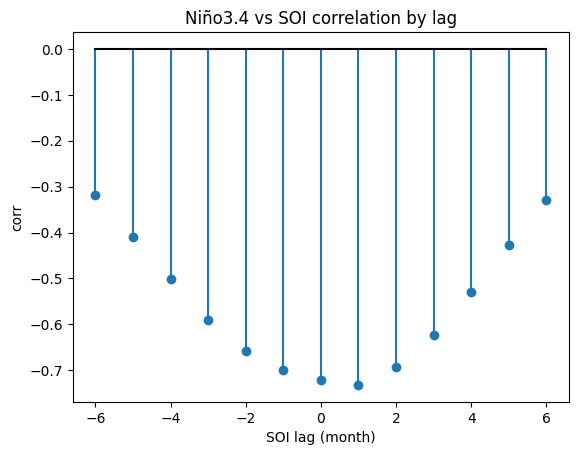

In [9]:
plt.stem(lags, corr, basefmt='k-')
plt.xlabel('SOI lag (month)'), plt.ylabel('corr')
plt.title('Niño3.4 vs SOI correlation by lag')
plt.show()


In [5]:
enso_phase = classify_enso_events(ssta)

In [6]:
print(enso_phase.head())

       start        end    phase  peak_ONI
0 1950-02-15 1951-03-15  La Niña -1.206667
1 1951-08-15 1951-12-15  El Niño  0.786667
2 1954-05-15 1956-12-15  La Niña -1.673333
3 1957-06-15 1958-04-15  El Niño  1.373333
4 1963-07-15 1964-01-15  El Niño  0.880000


In [7]:
def plot_enso_timeseries_bar(ssta: pd.DataFrame,
                              soi: pd.DataFrame,
                              enso_events: pd.DataFrame):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    # 合併 SSTA 和 SOI
    df = ssta.join(soi, how='inner')

    # 展平 ENSO 事件為每月資料
    enso_long = []
    for _, row in enso_events.iterrows():
        period = pd.date_range(start=row["start"], end=row["end"], freq="MS")
        for date in period:
            enso_long.append({
                "date": date.replace(day=15),
                "phase": row["phase"]
            })
    enso_long = pd.DataFrame(enso_long)
    enso_long.set_index("date", inplace=True)

    # 加入 SSTA 值
    enso_long = enso_long.join(ssta)

    # 建立 bar 資料
    enso_colors = []
    enso_bar_values = []
    for _, row in enso_long.iterrows():
        val = row['ssta']
        if row['phase'] == "El Niño":
            enso_colors.append('red')
            enso_bar_values.append(val)
        elif row['phase'] == "La Niña":
            enso_colors.append('blue')
            enso_bar_values.append(val)  # 負值顯示向下
        else:
            enso_colors.append('lightgray')
            enso_bar_values.append(0)

    # 建立圖表
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True,
                             gridspec_kw={'height_ratios': [1.2, 1, 0.6]})

    # Plot 1: Niño 3.4 SSTA
    axes[0].plot(df.index, df['ssta'], color='cornflowerblue', lw=1)
    axes[0].set_ylabel("SST Anomaly (°C)")
    axes[0].legend(["Niño 3.4 SSTA"], loc='upper left')
    axes[0].axhline(0, color='black', linewidth=0.5)

    # Plot 2: SOI
    axes[1].plot(df.index, df['SOI'], color='black', lw=1)
    axes[1].set_ylabel("SOI Index")
    axes[1].legend(["SOI"], loc='upper left')
    axes[1].axhline(0, color='black', linewidth=0.5)

    # Plot 3: ENSO Events
    axes[2].bar(enso_long.index, enso_bar_values, color=enso_colors, width=20)
    axes[2].axhline(y=1.5, linestyle="--", color="red", label="Strong El Niño")
    axes[2].axhline(y=-1.5, linestyle="--", color="blue", label="Strong La Niña")
    axes[2].set_ylabel("ENSO Phase\n(Bar ~ SSTA)")
    axes[2].set_ylim(-2.5, 2.5)
    axes[2].legend(loc='upper left')

    # X-axis formatting
    axes[-1].xaxis.set_major_locator(mdates.YearLocator(5))
    axes[-1].xaxis.set_minor_locator(mdates.YearLocator(1))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[-1].grid(True, axis='x', which='major', linestyle='--', alpha=0.3)

    plt.suptitle("ENSO Time Series: Niño 3.4 SSTA, SOI, and ENSO Classification (ONI Rule)", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


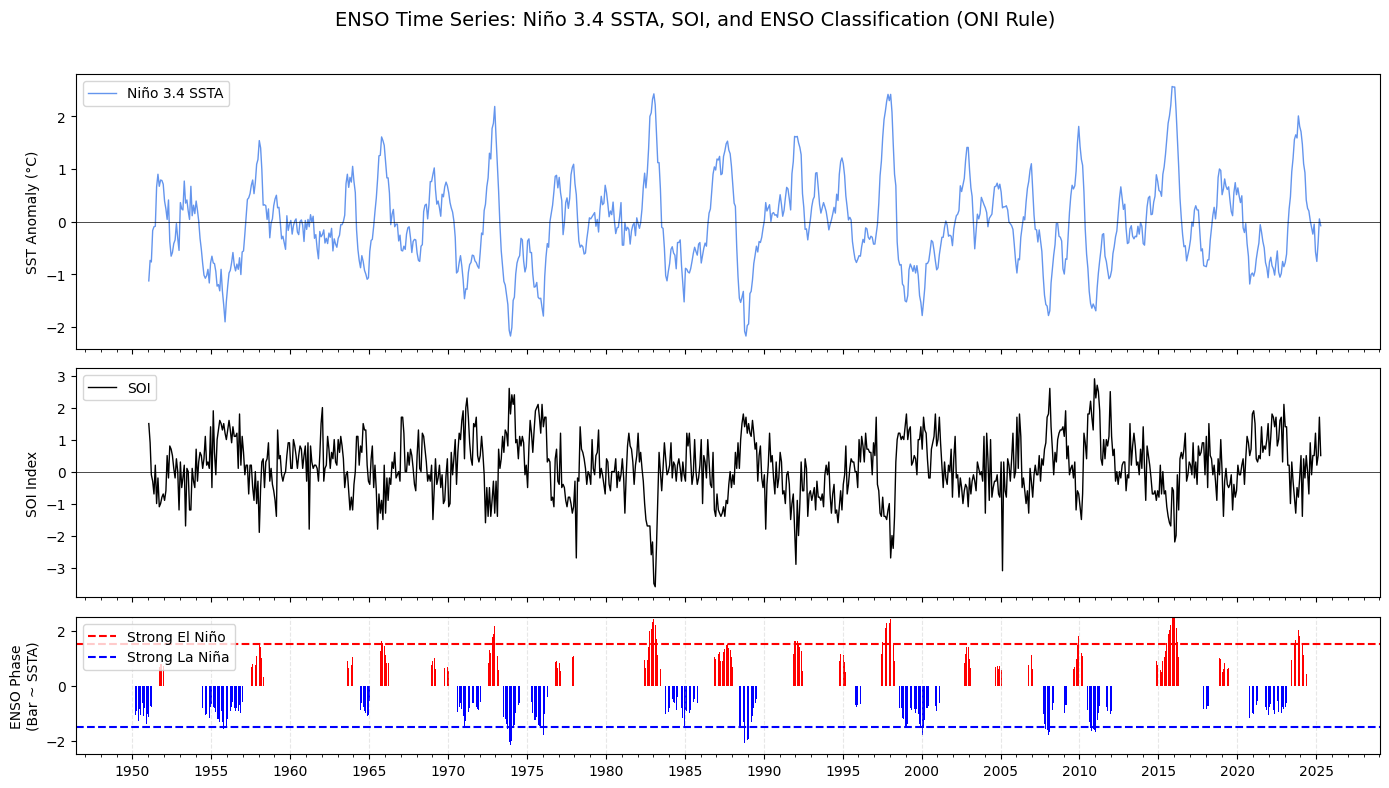

In [11]:
plot_enso_timeseries_bar(ssta, soi, enso_phase)

In [76]:
# Fetch MHW data year by year for the Mediterranean region
def fetch_yearly_data(lon0, lat0, lon1, lat1, start_year, end_year):
    all_data = []
    for year in range(start_year, end_year + 1):
        start = f"{year}-01-01"
        end = f"{year}-12-31"
        print(f"Fetching data for {start} to {end}...")
        yearly_data = fetch_mhw_data(lon0, lat0, lon1, lat1, start, end)
        if yearly_data is not None:
            all_data.append(yearly_data)
    if all_data:
        return pd.concat(all_data, ignore_index=True)
    else:
        return None

In [77]:
start_year, end_year = 1982, 2024  # Iterate year range to get MHW data
ylon0, ylat0, ylon1, ylat1 = -170, -5, -120, 5  # Niño 3.4 region
ydata = fetch_yearly_data(ylon0, ylat0, ylon1, ylat1, start_year, end_year)

Fetching data for 1982-01-01 to 1982-12-31...
Fetching data for 1983-01-01 to 1983-12-31...
Fetching data for 1984-01-01 to 1984-12-31...
Fetching data for 1985-01-01 to 1985-12-31...
Fetching data for 1986-01-01 to 1986-12-31...
Fetching data for 1987-01-01 to 1987-12-31...
Fetching data for 1988-01-01 to 1988-12-31...
Fetching data for 1989-01-01 to 1989-12-31...
Fetching data for 1990-01-01 to 1990-12-31...
Fetching data for 1991-01-01 to 1991-12-31...
Fetching data for 1992-01-01 to 1992-12-31...
Fetching data for 1993-01-01 to 1993-12-31...
Fetching data for 1994-01-01 to 1994-12-31...
Fetching data for 1995-01-01 to 1995-12-31...
Fetching data for 1996-01-01 to 1996-12-31...
Fetching data for 1997-01-01 to 1997-12-31...
Fetching data for 1998-01-01 to 1998-12-31...
Fetching data for 1999-01-01 to 1999-12-31...
Fetching data for 2000-01-01 to 2000-12-31...
Fetching data for 2001-01-01 to 2001-12-31...
Fetching data for 2002-01-01 to 2002-12-31...
Fetching data for 2003-01-01 to 20

In [78]:
print(ydata.head())

       lon    lat        date  level        sst  sst_anomaly
0 -169.875 -4.875  1982-01-01      0  28.876776       0.0775
1 -169.625 -4.875  1982-01-01      0  28.823547       0.0411
2 -169.375 -4.875  1982-01-01      0  28.722580      -0.0456
3 -169.125 -4.875  1982-01-01      0  28.680967      -0.0614
4 -168.875 -4.875  1982-01-01      0  28.675159      -0.0333


In [ ]:
#ydata.to_csv("../data/nino34_mhw_1982-2024.csv", index=False)

In [87]:
nino_mean = ydata.groupby("date")["sst_anomaly"].mean()
nino_mean.index = pd.to_datetime(nino_mean.index)
print(nino_mean.head())
print(len(nino_mean))

date
1982-01-01    0.181876
1982-02-01   -0.139610
1982-03-01   -0.026869
1982-04-01    0.198018
1982-05-01    0.650803
Name: sst_anomaly, dtype: float64
516


In [ ]:
# For reloading...
# nino_mean.to_csv("../data/nino34_mean_1982-2024.csv", index=False)

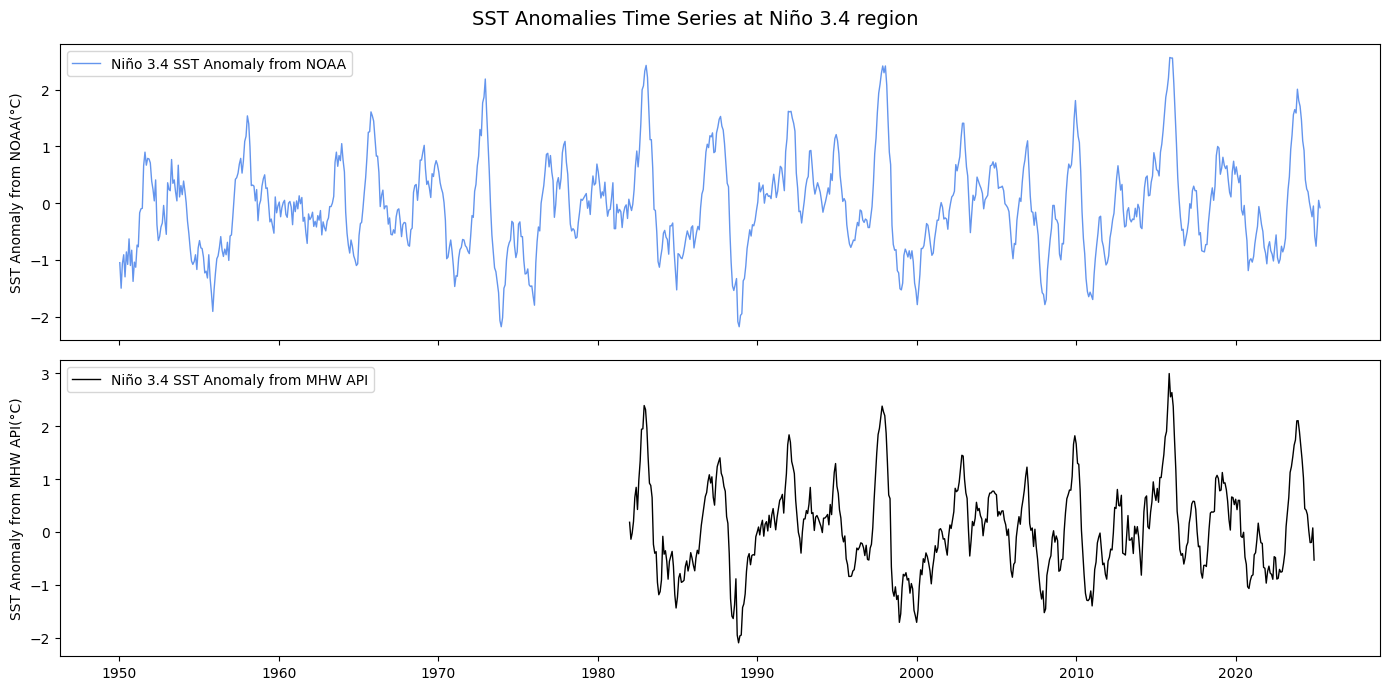

In [89]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Plot 1: Niño 3.4 SST anomaly
axes[0].plot(ssta.index, ssta, color='cornflowerblue', lw=1)
axes[0].set_ylabel("SST Anomaly from NOAA(°C)")
axes[0].legend(["Niño 3.4 SST Anomaly from NOAA"], loc='upper left')

# Plot 2: Data from MHW API
axes[1].plot(nino_mean.index, nino_mean, color='black', lw=1)
axes[1].set_ylabel("SST Anomaly from MHW API(°C)")
axes[1].legend(["Niño 3.4 SST Anomaly from MHW API"], loc='upper left')

plt.suptitle("SST Anomalies Time Series at Niño 3.4 region", fontsize=14)
fig.tight_layout()


In [ ]:
import requests
from io import StringIO
# refer to https://www.nature.com/articles/s41598-018-38034-z
# Global Disease Outbreaks Associated with the 2015–2016 El Niño Event

# Load the Tanzania cholera data
cholera_df = pd.read_csv('../data/tanzania_cholera_detrended.csv')
print(cholera_df)


    year  detrended_cholera_cases
0   2000             -2111.111111
1   2001             -5068.376068
2   2002              4801.975802
3   2003             -5337.218337
4   2004              3572.982573
5   2005             -3071.262071
6   2006              7451.992452
7   2007             -4069.819070
8   2008             -2764.013764
9   2009              1767.898768
10  2010             -1035.742036
11  2011             -4185.037185
12  2012             -4722.721723
13  2013             -4607.503608
14  2014             -4722.721723
15  2015              5838.938839
16  2016              5915.750916
17  2017               116.439116


In [13]:
# Step 1: Get ENSO data
nino_df = get_nino34_anomalies("1999", "2018")
events_df = classify_enso_events(nino_df)

# Step 2: Extract the dominant ENSO phase per year
nino_df["year"] = nino_df.index.year
nino_df["month"] = nino_df.index.month

print(nino_df.head())
print(events_df.head())


            ssta  year  month
date                         
1999-01-15 -1.53  1999      1
1999-02-15 -1.41  1999      2
1999-03-15 -0.92  1999      3
1999-04-15 -0.81  1999      4
1999-05-15 -0.87  1999      5
       start        end    phase  peak_ONI
0 1999-02-15 2000-07-15  La Niña -1.620000
1 2000-10-15 2001-02-15  La Niña -0.850000
2 2002-07-15 2003-02-15  El Niño  1.326667
3 2004-08-15 2005-01-15  El Niño  0.686667
4 2006-09-15 2007-01-15  El Niño  0.946667


In [14]:
mask = (nino_df["month"] >= 11) | (nino_df["month"] <= 4)
nino_active = nino_df[mask]

enso_by_year = nino_active.groupby("year")["ssta"].rolling(window=3, center=True).mean().reset_index(level=0, drop=True)
enso_phases = enso_by_year.groupby(enso_by_year.index.year).apply(
    lambda x: "El Niño" if x.mean() >= 0.5 else "La Niña" if x.mean() <= -0.5 else "Neutral"
).reset_index()
enso_phases.columns = ["year", "enso_phase"]

In [15]:
nino_df["oni_3mo"] = nino_df["ssta"].rolling(window=3, center=True).mean()

# Step 2: Extract DJF (Dec of prev year, Jan, Feb of current year)
oni_djf = []
for year in range(2000, 2018 + 1):
    dec_prev = pd.Timestamp(year=year - 1, month=12, day=15)
    jan = pd.Timestamp(year=year, month=1, day=15)
    feb = pd.Timestamp(year=year, month=2, day=15)
    vals = nino_df.loc[[dec_prev, jan, feb], "oni_3mo"].dropna()
    if len(vals) == 3:
        oni_djf.append({"year": year, "oni_djf": vals.mean()})
    else:
        oni_djf.append({"year": year, "oni_djf": None})

oni_djf_df = pd.DataFrame(oni_djf)
print(oni_djf_df)

    year   oni_djf
0   2000 -1.575556
1   2001 -0.774444
2   2002 -0.167778
3   2003  0.992222
4   2004  0.227778
5   2005  0.502222
6   2006 -0.781111
7   2007  0.560000
8   2008 -1.637778
9   2009 -0.812222
10  2010  1.425556
11  2011 -1.492222
12  2012 -0.853333
13  2013 -0.236667
14  2014 -0.270000
15  2015  0.646667
16  2016  2.354444
17  2017 -0.308889
18  2018 -0.812222


In [16]:
# Merge
merged_df = cholera_df.merge(enso_phases, on="year", how="left")
merged_df = merged_df.merge(oni_djf_df, on="year", how="left")

# Display the merged result
# tools.display_dataframe_to_user(name="Cholera vs ENSO Phase", dataframe=merged_df)
print(merged_df)


    year  detrended_cholera_cases enso_phase   oni_djf
0   2000             -2111.111111    La Niña -1.575556
1   2001             -5068.376068    Neutral -0.774444
2   2002              4801.975802    Neutral -0.167778
3   2003             -5337.218337    Neutral  0.992222
4   2004              3572.982573    Neutral  0.227778
5   2005             -3071.262071    Neutral  0.502222
6   2006              7451.992452    Neutral -0.781111
7   2007             -4069.819070    Neutral  0.560000
8   2008             -2764.013764    La Niña -1.637778
9   2009              1767.898768    Neutral -0.812222
10  2010             -1035.742036    Neutral  1.425556
11  2011             -4185.037185    La Niña -1.492222
12  2012             -4722.721723    Neutral -0.853333
13  2013             -4607.503608    Neutral -0.236667
14  2014             -4722.721723    Neutral -0.270000
15  2015              5838.938839    El Niño  0.646667
16  2016              5915.750916    El Niño  2.354444
17  2017  

In [17]:
def plot_cholera_vs_enso(cholera_df, nino_df, events_df):
    import matplotlib.pyplot as plt

    # Prepare ONI 3-month moving average (masked/clean)
    oni = nino_df['ssta'].rolling(window=3, center=True).mean().dropna().astype(float)

    # Flatten ENSO events into monthly records for bar heights
    enso_long = []
    for _, row in events_df.iterrows():
        period = pd.date_range(start=row["start"], end=row["end"], freq="MS")
        for date in period:
            enso_long.append({"date": date.replace(day=15), "phase": row["phase"]})
    enso_long = pd.DataFrame(enso_long).set_index("date")
    enso_long = enso_long.join(nino_df["ssta"], how="left")

    # Determine colors and bar heights
    enso_colors = []
    enso_bar_values = []
    for _, row in enso_long.iterrows():
        val = row['ssta']
        if row['phase'] == "El Niño":
            enso_colors.append('red')
            enso_bar_values.append(val)
        elif row['phase'] == "La Niña":
            enso_colors.append('blue')
            enso_bar_values.append(val)
        else:
            # neutral — optional: lightgray or zero height
            enso_colors.append('lightgray')
            enso_bar_values.append(0)

    # Plotting
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # 1. Gray shaded full ONI curve
    ax1.fill_between(oni.index, oni, 0, color='gray', alpha=0.3, label='ONI 3mo mean')

    # 2. Red/blue bars for ENSO months
    ax1.bar(enso_long.index, enso_bar_values, width=20, color=enso_colors, alpha=0.7, label='ENSO anomaly')

    # 3. Cholera annual points at mid-year
    ax2 = ax1.twinx()
    cholera_dates = pd.to_datetime(cholera_df["year"].astype(str)) + pd.DateOffset(months=5, days=15)
    ax2.plot(cholera_dates, cholera_df["detrended_cholera_cases"], 'ko-', label='Cholera Cases')
    ax2.set_ylabel("Detrended Cholera Cases")

    # 4. Optional: DJF ONI dashed line
    if "oni_djf" in cholera_df.columns:
        ax2.plot(cholera_dates, cholera_df["oni_djf"] * 1000, 'k--', alpha=0.5, label="DJF ONI ×1000")

    # Labels, limits, legends
    ax1.set_ylabel("Niño 3.4 SSTA (°C)")
    ax1.set_xlim(pd.Timestamp("1999-01-01"), pd.Timestamp("2018-12-31"))
    ax1.set_title("Tanzania Cholera vs Monthly ONI & ENSO Anomalies (bars)")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.tight_layout()
    plt.show()


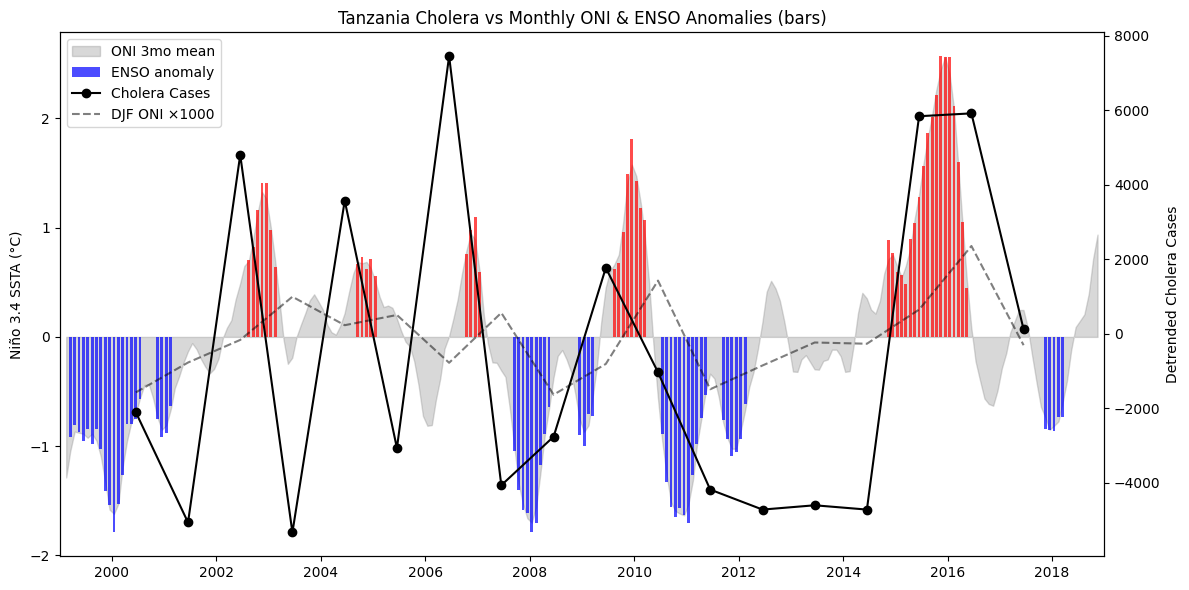

In [33]:
plot_cholera_vs_enso(merged_df, nino_df, events_df)

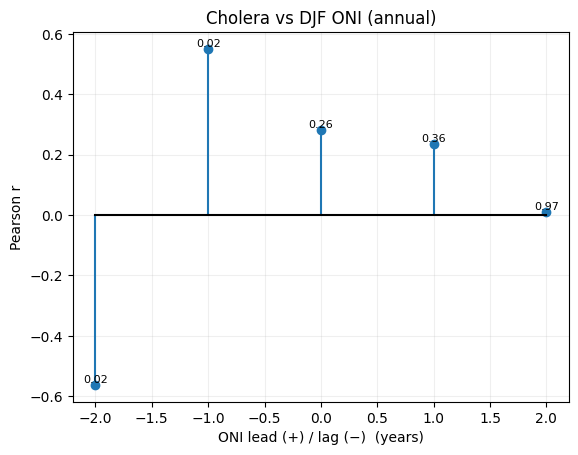

In [18]:
from scipy.stats import pearsonr
import pandas as pd, matplotlib.pyplot as plt, numpy as np

chol = merged_df.set_index('year')['detrended_cholera_cases']
oni  = merged_df.set_index('year')['oni_djf']

lags = range(-2, 3)          # ONI lead (+) / lag (−)
corr, pval = [], []
for l in lags:
    pair = pd.concat([chol, oni.shift(l)], axis=1).dropna()
    r, p = pearsonr(pair.iloc[:,0], pair.iloc[:,1])
    corr.append(r); pval.append(p)

plt.stem(lags, corr, basefmt='k-')
for x,y,p in zip(lags, corr, pval):
    plt.text(x, y, f'{p:.2f}', ha='center', va='bottom', fontsize=8)
plt.xlabel('ONI lead (+) / lag (−)  (years)')
plt.ylabel('Pearson r')
plt.title('Cholera vs DJF ONI (annual)')
plt.grid(alpha=.2)
plt.show()

enso_phase
El Niño     2
La Niña     3
Neutral    13
dtype: int64


C:\Users\bioer\AppData\Local\Temp\ipykernel_22172\302493546.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='enso_phase', y='detrended_cholera_cases',


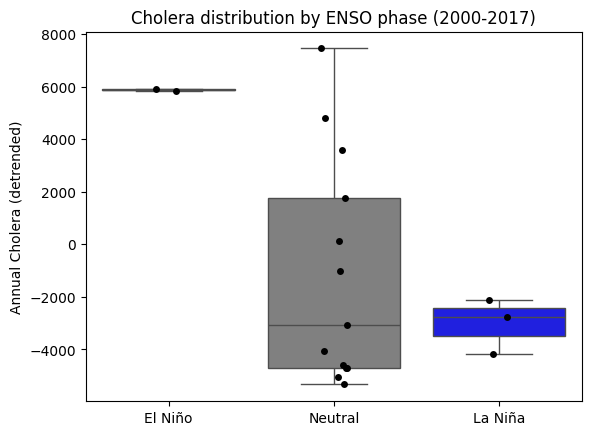

In [19]:
import seaborn as sns, matplotlib.pyplot as plt

# 分組樣本數
print(merged_df.groupby('enso_phase').size())

sns.boxplot(data=merged_df, x='enso_phase', y='detrended_cholera_cases',
            order=['El Niño','Neutral','La Niña'],
            showfliers=False, palette={'El Niño':'red','La Niña':'blue','Neutral':'gray'})
sns.stripplot(data=merged_df, x='enso_phase', y='detrended_cholera_cases',
              order=['El Niño','Neutral','La Niña'],
              color='black', jitter=True)
plt.ylabel('Annual Cholera (detrended)'); plt.xlabel('')
plt.title('Cholera distribution by ENSO phase (2000-2017)')
plt.show()


In [2]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 1. 讀取 CHIRPS 月降雨量資料（1981-2020）via OPeNDAP
# url = "https://coastwatch.pfeg.noaa.gov/erddap/files/chirps20GlobalMonthlyP05/chirps-v2.0.monthly.nc"
# 1. 讀取 CHIRPS 月降雨量資料（1981-2020）via OPeNDAP (htmlTable -> nc)
# 2. 切片：經度 28–42, 緯度 4 至 -12（覆蓋坦尚尼亞大部）
# url_nc = (
#  "https://coastwatch.pfeg.noaa.gov/erddap/griddap/chirps20GlobalMonthlyP05.nc?"
#  "precip[(1981-01-01T00:00:00Z):1:(2020-12-01T00:00:00Z)]"
#  "[(-12):1:(4)]"
#  "[(28):1:(42)]"
#)
# ds = xr.open_dataset(url)["precip"]

# 2. 讀進來
ds = xr.open_dataset("../data/chirps-v2.0.monthly.nc")
print(ds)


<xarray.Dataset> Size: 31GB
Dimensions:    (latitude: 2000, longitude: 7200, time: 530)
Coordinates:
  * latitude   (latitude) float32 8kB -49.97 -49.92 -49.88 ... 49.87 49.92 49.97
  * longitude  (longitude) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
  * time       (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2025-02-01
Data variables:
    precip     (time, latitude, longitude) float32 31GB ...
Attributes: (12/15)
    Conventions:       CF-1.6
    title:             CHIRPS Version 2.0
    history:           created by Climate Hazards Group
    version:           Version 2.0
    date_created:      2025-03-14
    creator_name:      Pete Peterson
    ...                ...
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    comments:           time variable denotes the first day of the given month.
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pub/org/ch

In [40]:
da = ds["precip"]  # dims: time, lat, lon
# 2. 切片：經度 28–42, 緯度 4 至 -12（覆蓋坦尚尼亞大部）
# 2. 切出坦尚尼亞區域（經緯度邊界）
da_tz = da.sel(latitude=slice(-12, 4), longitude=slice(28, 42))

print(da_tz)

<xarray.DataArray 'precip' (time: 530, latitude: 320, longitude: 280)> Size: 190MB
[47488000 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 1kB -11.98 -11.92 -11.88 ... 3.875 3.925 3.975
  * longitude  (longitude) float32 1kB 28.02 28.07 28.12 ... 41.88 41.93 41.97
  * time       (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2025-02-01
Attributes:
    units:               mm/month
    standard_name:       convective precipitation rate
    long_name:           Climate Hazards group InfraRed Precipitation with St...
    time_step:           month
    geostatial_lat_min:  -50.0
    geostatial_lat_max:  50.0
    geostatial_lon_min:  -180.0
    geostatial_lon_max:  180.0


In [41]:
# 3. 計算 climatology（1981–2010 每月平均）
clim = da_tz.sel(time=slice("1981-01-01", "2010-12-31"))\
            .groupby("time.month").mean("time")
print(clim)

<xarray.DataArray 'precip' (month: 12, latitude: 320, longitude: 280)> Size: 4MB
array([[[329.2484    , 325.3951    , 331.071     , ...,          nan,
                  nan,          nan],
        [328.4085    , 325.10318   , 329.23932   , ...,          nan,
                  nan,          nan],
        [328.7585    , 324.68484   , 327.4529    , ...,          nan,
                  nan,          nan],
        ...,
        [ 24.717102  ,  26.407297  ,  28.05042   , ...,   1.2034779 ,
           1.0297885 ,   1.0373799 ],
        [ 24.740398  ,  26.30026   ,  27.866058  , ...,   0.7205696 ,
           0.72458637,   1.090437  ],
        [ 24.794828  ,  26.239716  ,  28.619099  , ...,   0.77593523,
           0.7756237 ,   0.91285187]],

       [[249.6292    , 248.17564   , 246.53664   , ...,          nan,
                  nan,          nan],
        [246.12357   , 245.21526   , 244.34471   , ...,          nan,
                  nan,          nan],
        [243.35204   , 243.8166    , 244

In [43]:
# 4. 異常值 = 實測值 - 月平均
anom = da_tz.groupby("time.month") - clim
print(anom)

<xarray.DataArray 'precip' (time: 530, latitude: 320, longitude: 280)> Size: 190MB
array([[[-3.91324768e+01, -3.87864075e+01, -4.05466614e+01, ...,
                     nan,             nan,             nan],
        [-4.10361938e+01, -4.08266907e+01, -4.13666077e+01, ...,
                     nan,             nan,             nan],
        [-4.19821167e+01, -4.11684875e+01, -4.18063660e+01, ...,
                     nan,             nan,             nan],
        ...,
        [-4.38810730e+00, -4.96791267e+00, -5.54252434e+00, ...,
         -2.52404690e-01, -2.19449997e-01, -2.08210349e-01],
        [-4.58907890e+00, -5.16963387e+00, -5.70517159e+00, ...,
         -1.49995327e-01, -1.52872384e-01, -2.26656973e-01],
        [-4.72354698e+00, -5.41880989e+00, -5.76087570e+00, ...,
         -1.53576612e-01, -1.63334668e-01, -2.09788859e-01]],

       [[-3.99508667e+01, -4.02420807e+01, -4.12456512e+01, ...,
                     nan,             nan,             nan],
        [-3.83979034

In [ ]:
# 5. 空間平均，再轉為 pandas.Series（因為 anom 是 DataArray，不是 Dataset）
rain_anom = anom.mean(dim=["latitude", "longitude"]).to_series()

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(rain_anom)

In [54]:
rain_anom.to_csv("../data/tanzania_rain_anomaly_1981-2025.csv", header=True)

In [46]:
# 6. 準備 cholera 資料
chol_dates = pd.to_datetime(merged_df['year'].astype(str)) + pd.DateOffset(months=5, days=15)
chol = pd.Series(merged_df['detrended_cholera_cases'].values,
                 index=chol_dates, name="cholera")

In [48]:
oni = nino_df['ssta'].rolling(window=3, center=True).mean().dropna().astype(float)

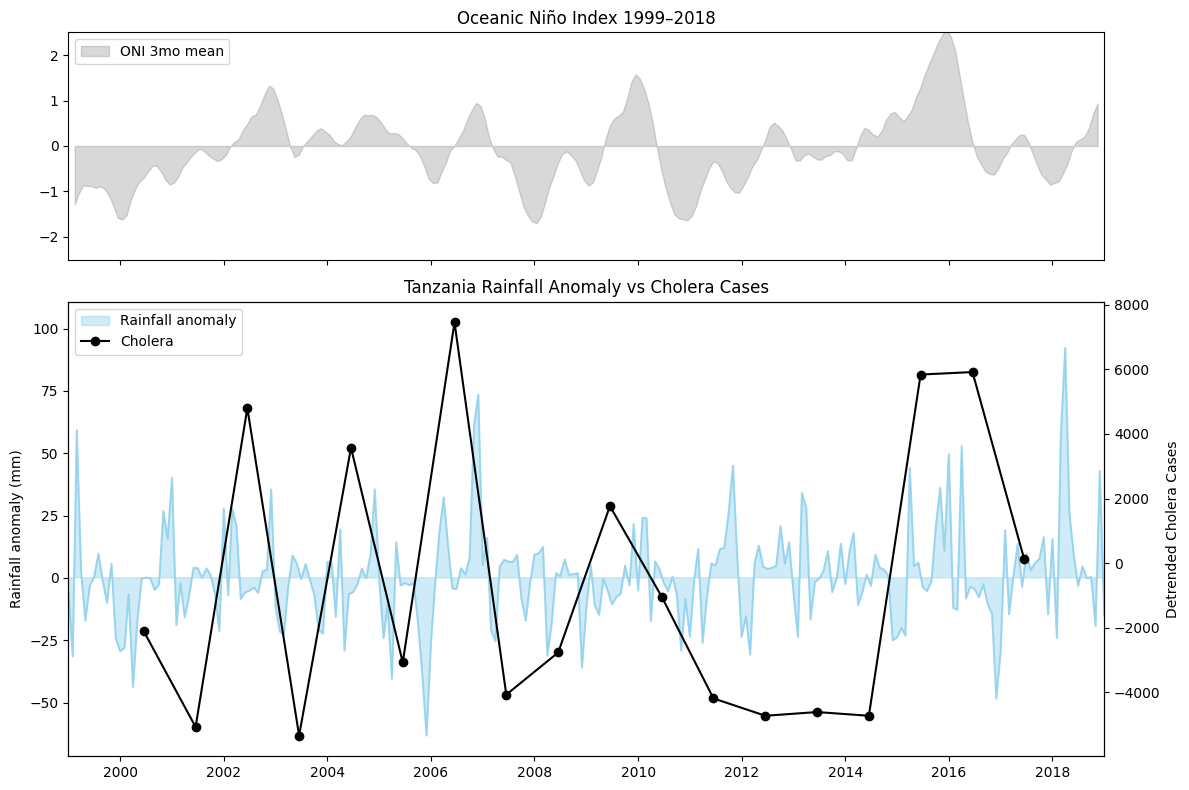

In [51]:
# 7. 繪圖
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                     gridspec_kw={"height_ratios": [1, 2]})

# Top: ONI DJF
ax_top.fill_between(oni.index, oni, 0, color='gray', alpha=0.3, label='ONI 3mo mean')
ax_top.set_ylim(-2.5, 2.5)
ax_top.set_title("Oceanic Niño Index 1999–2018") 
ax_top.legend(loc="upper left")

# Bottom: Rain anomaly + Cholera
ax_bot.fill_between(rain_anom.index, rain_anom, 0, color='skyblue', alpha=0.4, label="Rainfall anomaly")
ax_bot.plot(rain_anom.index, rain_anom, color='skyblue', alpha=0.7)
ax_bot.set_ylabel("Rainfall anomaly (mm)")

ax2 = ax_bot.twinx()
ax2.plot(chol.index, chol.values, 'ko-', label="Cholera")
ax2.set_ylabel("Detrended Cholera Cases")

ax_bot.set_xlim(pd.Timestamp('1999-01-01'), pd.Timestamp('2018-12-31'))
ax_bot.set_title("Tanzania Rainfall Anomaly vs Cholera Cases")

# Legend
h1, l1 = ax_bot.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()